# Notebook 2 - Create and Validate the Delivery Label

## Goal

Create `is_late` by comparing the actual customer delivery timestamp with the estimated delivery timestamp. Validate the rule on real orders and quantify class imbalance.

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
ARTIFACTS = ROOT / "artifacts"
FIGURES = ROOT / "figures"
REPORTS = ROOT / "reports"
for folder in [ARTIFACTS, FIGURES, REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)
print(f"Task root: {ROOT.resolve()}")

Task root: C:\Users\moath\Desktop\MLOPS\MLOps_Rand_Salem\MLOps-Qafza-2026\Tasks\Task-02


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

source = ARTIFACTS / "01_ml_table.parquet"
assert source.exists(), "Run Notebook 1 first."
ml_table = pd.read_parquet(source)
for column in ["order_delivered_customer_date", "order_estimated_delivery_date", "order_purchase_timestamp"]:
    ml_table[column] = pd.to_datetime(ml_table[column], errors="coerce")
print("Input shape:", ml_table.shape)

Input shape: (99441, 37)


## 1. Keep labelable delivered orders

In [3]:
labeled = ml_table.loc[
    ml_table["order_status"].eq("delivered")
    & ml_table["order_delivered_customer_date"].notna()
    & ml_table["order_estimated_delivery_date"].notna()
].copy()

labeled["is_late"] = (
    labeled["order_delivered_customer_date"] > labeled["order_estimated_delivery_date"]
).astype("int8")
labeled["delivery_delay_days"] = (
    labeled["order_delivered_customer_date"] - labeled["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

assert labeled["is_late"].isin([0, 1]).all()
print("Labelable orders:", len(labeled))

Labelable orders: 96470


## 2. Validate the label on actual orders

In [4]:
validation_sample = pd.concat([
    labeled.loc[labeled["is_late"].eq(1)].nsmallest(5, "delivery_delay_days"),
    labeled.loc[labeled["is_late"].eq(0)].nlargest(5, "delivery_delay_days"),
])[[
    "order_id", "order_delivered_customer_date", "order_estimated_delivery_date",
    "delivery_delay_days", "is_late",
]].sort_values("delivery_delay_days")

rule_check = (
    (validation_sample["delivery_delay_days"] > 0).astype(int)
    == validation_sample["is_late"]
)
assert rule_check.all()
validation_sample

,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_late
81823,21210d0eb0ac7cb1b22057ff1eca09c5,2018-04-11 23:58:47,2018-04-12,-0.000845,0
55577,cf3a11ded6899d6b589a1e4a4a4308c0,2018-03-28 23:58:48,2018-03-29,-0.000833,0
3559,9c5b6f458d5e5f8e372c112f8b658af6,2018-03-22 23:58:49,2018-03-23,-0.000822,0
44274,2b73cfa36a63e2ba82be54965d188a7e,2018-08-27 23:58:55,2018-08-28,-0.000752,0
84892,b07a843b1265472b48158269f4de8c36,2018-02-07 23:59:55,2018-02-08,-0.000058,0
82725,812f59f34238daae0b90419914cecbc1,2017-12-12 00:03:36,2017-12-12,0.002500,1
57212,0eae0847dbceff8611d706710c724ee2,2017-12-12 00:04:03,2017-12-12,0.002812,1
57100,c1ecc15bc30548ecad160437f07df801,2018-05-22 00:04:16,2018-05-22,0.002963,1
47556,5989369fa081195d8762312fad7d588d,2018-06-05 00:05:10,2018-06-05,0.003588,1
34736,308163f9666c3f335e92b0f0f61554ed,2018-08-01 00:05:14,2018-08-01,0.003634,1


## 3. Inspect class distribution

In [5]:
class_counts = labeled["is_late"].value_counts().sort_index()
class_summary = pd.DataFrame({
    "class": ["On time", "Late"],
    "label": [0, 1],
    "orders": [int(class_counts.get(0, 0)), int(class_counts.get(1, 0))],
})
class_summary["percentage"] = 100 * class_summary["orders"] / class_summary["orders"].sum()
class_summary

,class,label,orders,percentage
0,On time,0,88644,91.887633
1,Late,1,7826,8.112367


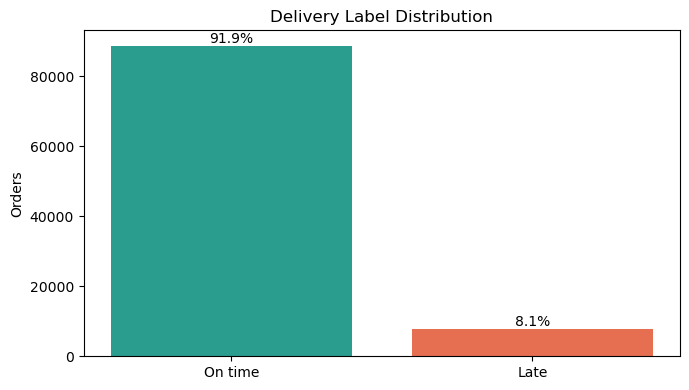

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(class_summary["class"], class_summary["orders"], color=["#2A9D8F", "#E76F51"])
ax.set(title="Delivery Label Distribution", ylabel="Orders")
for index, row in class_summary.iterrows():
    ax.text(index, row["orders"], f"{row['percentage']:.1f}%", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURES / "02_label_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## Decision

The positive (late) class is a clear minority. Accuracy alone would be misleading because a model can appear strong by predicting the majority class. Later evaluation therefore prioritizes PR-AUC, recall, F1, and balanced accuracy, with class weighting during model training.

## 4. Save the labeled artifact

In [7]:
artifact_path = ARTIFACTS / "02_labeled_orders.parquet"
labeled.to_parquet(artifact_path, index=False)

summary = {
    "artifact": artifact_path.name,
    "rows": int(len(labeled)),
    "on_time": int(class_counts.get(0, 0)),
    "late": int(class_counts.get(1, 0)),
    "late_rate": float(labeled["is_late"].mean()),
    "imbalance_ratio_on_time_to_late": float(class_counts.get(0, 0) / class_counts.get(1, 1)),
}
(REPORTS / "02_label_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(f"Saved: {artifact_path}")
summary

Saved: C:\Users\moath\Desktop\MLOPS\MLOps_Rand_Salem\MLOps-Qafza-2026\Tasks\Task-02\artifacts\02_labeled_orders.parquet


{'artifact': '02_labeled_orders.parquet',
 'rows': 96470,
 'on_time': 88644,
 'late': 7826,
 'late_rate': 0.08112366538820359,
 'imbalance_ratio_on_time_to_late': 11.326859187324304}